# Supplementary: Masking strategies

> Quick visual reference for every class in `shapiq.vision.masking`. For end-to-end explanations across models, use `tutorial_01_player_masker_strategies.ipynb`.

# Masking strategies

This notebook walks through every class in `shapiq.vision.masking` on one image and a fixed 2×2 player grid.

**Pixel space** (`PixelMaskingStrategy.apply`) rewrites absent regions before a CNN or pixel Hugging Face model runs.

* `MeanColorMasking` fills with the image mean color (default on ResNet and most pixel architectures)
* `ZeroMasking` fills with a constant, usually zero
* `BlurMasking` fills with a Gaussian-blurred copy of the image
* `DatasetMeanMasking` fills with a fixed dataset-wide mean (defaults to ImageNet RGB means)
* `GaussianNoiseMasking` fills with Gaussian noise (stochastic baseline)

**Latent space** (`LatentMaskingStrategy.predict_logits`) masks patch tokens inside a ViT forward pass via `bool_masked_pos`.

* `BoolMaskedPosStrategy` uses the Hugging Face masked-attention path
* `MaskTokenStrategy` zeros the mask-token embedding (default on `ViTArchitecture`)

The pixel section shows the masked images. The ViT section shows which tokens are absent and how the target-class probability changes for three coalitions.


In [1]:
from __future__ import annotations

from io import BytesIO

import matplotlib.pyplot as plt
import numpy as np
import requests
import torch
from PIL import Image
from torchvision import transforms

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


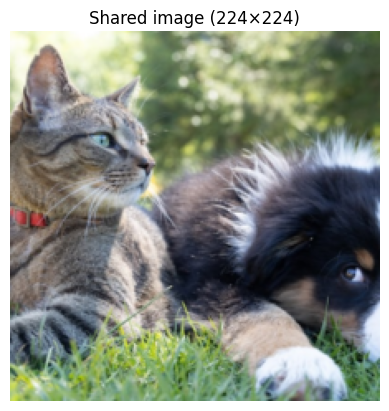

In [2]:
URL = (
    "https://images.unsplash.com/photo-1623387641168-d9803ddd3f35?"
    "q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0"
)
raw = Image.open(BytesIO(requests.get(URL, timeout=30).content)).convert("RGB")
resize = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])
pil_image = resize(raw)
image = np.array(pil_image)

plt.imshow(image)
plt.title("Shared image (224×224)")
plt.axis("off")
plt.show()

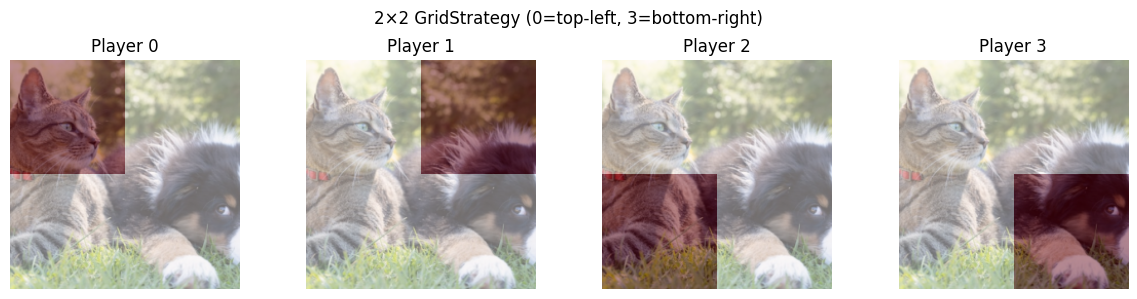

In [3]:
from shapiq.vision.players import GridStrategy

grid = GridStrategy(rows=2, cols=2)
player_masks = grid.get_masks(image)
H, W = image.shape[:2]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(image)
    ax.imshow(player_masks[i], alpha=0.45, cmap="Reds")
    ax.set_title(f"Player {i}")
    ax.axis("off")
plt.suptitle("2×2 GridStrategy (0=top-left, 3=bottom-right)")
plt.tight_layout()
plt.show()

## Pixel-space masking

Each row is one strategy. Columns are three coalitions on the same grid: everything visible, only the bottom-right player visible, and nothing visible.


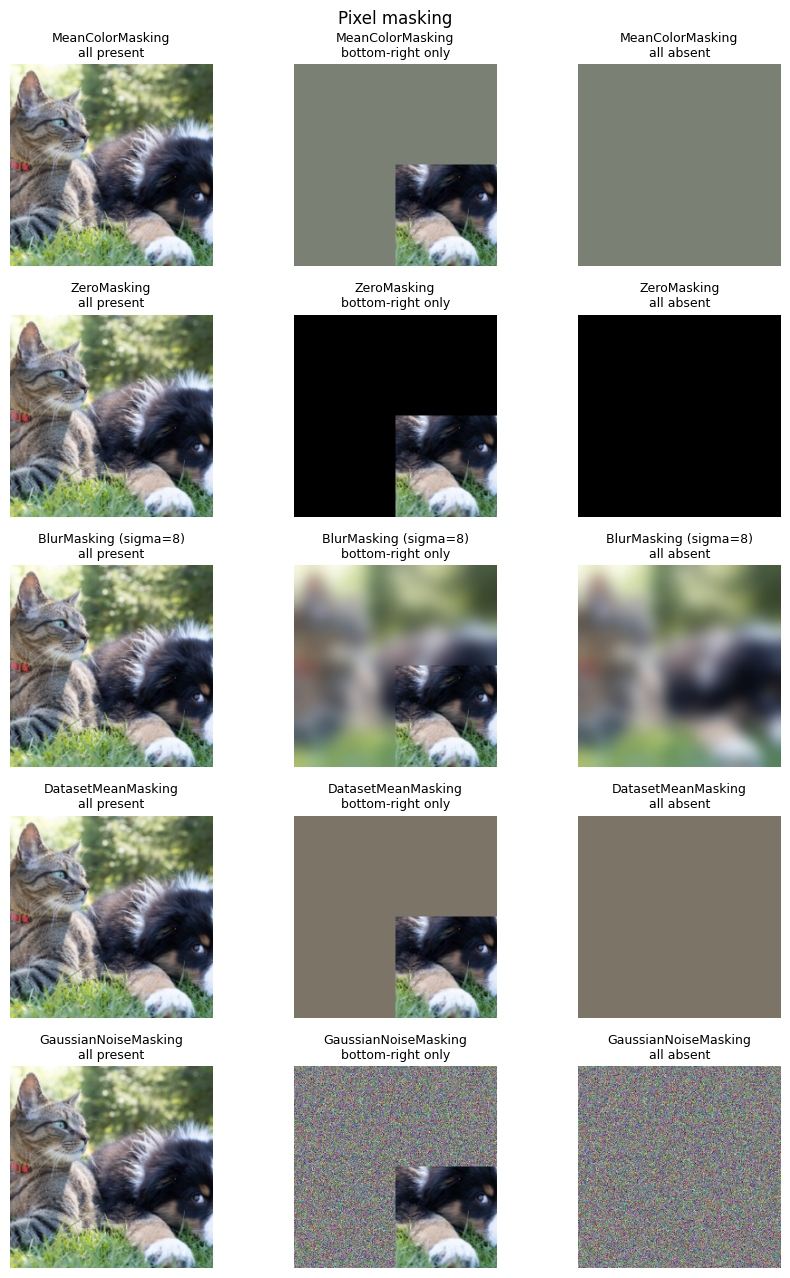

In [4]:
from shapiq.vision.masking import (
    BlurMasking,
    DatasetMeanMasking,
    GaussianNoiseMasking,
    MeanColorMasking,
    ZeroMasking,
)

IMAGENET_MEAN_RGB = np.array([0.485, 0.456, 0.406]) * 255

pixel_strategies = [
    ("MeanColorMasking", MeanColorMasking()),
    ("ZeroMasking", ZeroMasking()),
    ("BlurMasking (sigma=8)", BlurMasking(sigma=8)),
    ("DatasetMeanMasking", DatasetMeanMasking(mean_color=IMAGENET_MEAN_RGB)),
    (
        "GaussianNoiseMasking",
        GaussianNoiseMasking(mean=128.0, std=40.0, random_state=0),
    ),
]

coalition_labels = [
    ("all present", np.array([[True, True, True, True]])),
    ("bottom-right only", np.array([[False, False, False, True]])),
    ("all absent", np.array([[False, False, False, False]])),
]

fig, axes = plt.subplots(len(pixel_strategies), len(coalition_labels), figsize=(9, 13))
for row, (name, strategy) in enumerate(pixel_strategies):
    batch = np.concatenate([coal for _, coal in coalition_labels], axis=0)
    masked = strategy.apply(image, player_masks, batch)
    for col, (coal_label, _) in enumerate(coalition_labels):
        ax = axes[row, col]
        ax.imshow(np.clip(masked[col], 0, 255).astype(np.uint8))
        ax.set_title(f"{name}\n{coal_label}", fontsize=9)
        ax.axis("off")
plt.suptitle("Pixel masking")
plt.tight_layout()
plt.show()

## Latent-space masking (ViT)

Latent maskers keep the original pixels. They pass `bool_masked_pos` to the model, where `True` means the token is absent. The panels darken absent tokens. The bar chart uses the same three coalitions and the class ViT predicts on the full image.

On this crop the dog sits in the bottom-right quadrant, so `bottom-right only` keeps most of the class signal while `top-left only` would be near zero.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViT target class: Bernese mountain dog


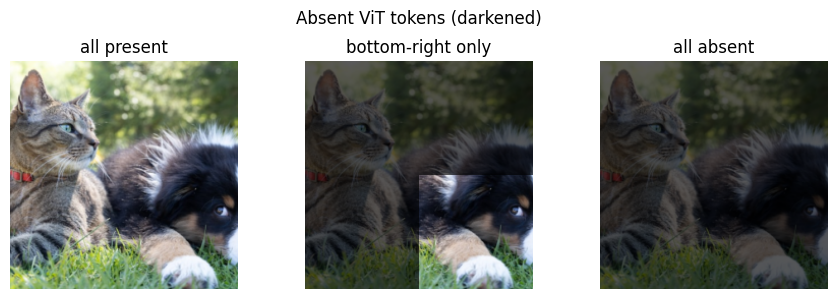

In [5]:
from transformers import ViTForImageClassification, ViTImageProcessor

from shapiq.vision.masking import BoolMaskedPosStrategy, MaskTokenStrategy
from shapiq.vision.players import PatchStrategy

vit_id = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(vit_id)
vit_model = ViTForImageClassification.from_pretrained(vit_id).eval().to(device)

grid_size = vit_model.config.image_size // vit_model.config.patch_size
patch_players = PatchStrategy(grid_size=grid_size, n_players=4)

inputs = processor(images=image, return_tensors="pt")
pixel_values = inputs["pixel_values"].to(device)
with torch.no_grad():
    class_id = int(vit_model(pixel_values=pixel_values).logits.argmax(-1).item())
target_label = vit_model.config.id2label[class_id]
print("ViT target class:", target_label)


def latent_preview(coalition: np.ndarray) -> np.ndarray:
    bool_mask = patch_players.get_latent_mask(coalition).reshape(grid_size, grid_size).cpu().numpy()
    preview = image.astype(np.float64).copy()
    ph, pw = H // grid_size, W // grid_size
    for r in range(grid_size):
        for c in range(grid_size):
            if bool_mask[r, c]:
                y0, y1 = r * ph, (r + 1) * ph
                x0, x1 = c * pw, (c + 1) * pw
                preview[y0:y1, x0:x1] *= 0.35
    return preview.astype(np.uint8)


latent_coalitions = [
    ("all present", np.array([True, True, True, True])),
    ("bottom-right only", np.array([False, False, False, True])),
    ("all absent", np.array([False, False, False, False])),
]

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, (label, coal) in zip(axes, latent_coalitions, strict=False):
    ax.imshow(latent_preview(coal))
    ax.set_title(label)
    ax.axis("off")
plt.suptitle("Absent ViT tokens (darkened)")
plt.tight_layout()
plt.show()

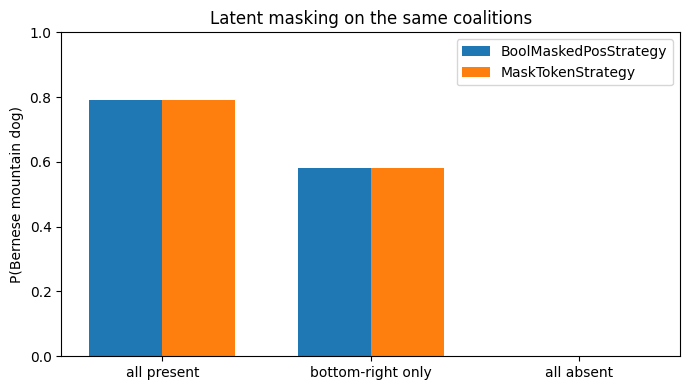

In [6]:
latent_strategies = [
    ("BoolMaskedPosStrategy", BoolMaskedPosStrategy()),
    ("MaskTokenStrategy", MaskTokenStrategy()),
]

x = np.arange(len(latent_coalitions))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))

for offset, (name, strategy) in enumerate(latent_strategies):
    probs = []
    for _, coal in latent_coalitions:
        bool_masks = patch_players.get_latent_mask(coal).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = strategy.predict_logits(vit_model, pixel_values, bool_masks)
            prob = torch.softmax(logits, dim=-1)[0, class_id].item()
        probs.append(prob)
    ax.bar(x + offset * width, probs, width=width, label=name)

ax.set_xticks(x + width / 2)
ax.set_xticklabels([label for label, _ in latent_coalitions])
ax.set_ylabel(f"P({target_label})")
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("Latent masking on the same coalitions")
plt.tight_layout()
plt.show()

## Production strategies

The four strategies above (mean / zero / blur on pixels, BoolMaskedPos / MaskToken
on tokens) cover the published baselines. The three strategies below add to that:

- **`MarginalSampling`** — fits Covert et al.'s *marginal* removal slot (Covert,
  Lundberg & Lee, JMLR 2021): replace absent pixels with samples from the data
  distribution rather than a constant fill.
- **`InpaintingMasking`** — fits Covert et al.'s *conditional* removal slot:
  replace absent pixels by what the rest of the image suggests they should be.
  shapiq ships the wrapper only; the user brings the inpainter.
- **`LayerMasking`** — outside Covert's input-space framework: intervene
  in-model by attenuating intermediate CNN activations via a forward hook
  (Balasubramanian & Feizi, *Towards Improved Input Masking for CNNs*, ICCV 2023).
  The CNN analogue of `MaskTokenStrategy` for ViT.

Covert's fourth slot — *missingness during training* (e.g., INVASE) — requires
retraining the model to handle missing inputs and is out of scope for a library
that wraps pretrained vision models.


### MarginalSampling — pixel samples from a reference bank

For each coalition, draws a reference image uniformly at random and pastes its pixels
into the absent region. Closer to the data manifold than a constant fill, deterministic
with `random_state`.


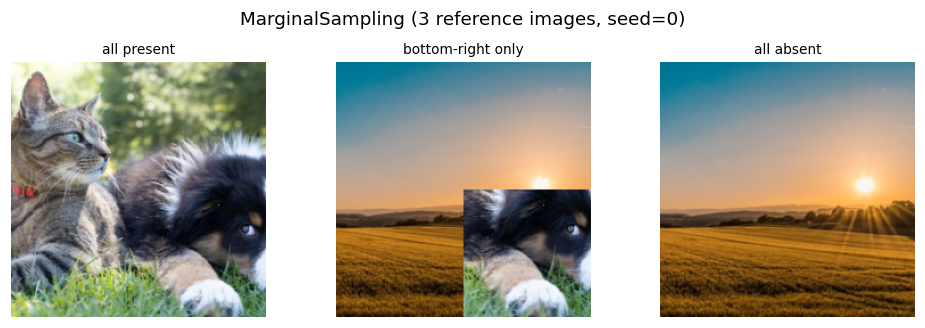

In [7]:
from shapiq.vision.masking import MarginalSampling

# Build a small reference bank (3 unrelated images, same shape as `image`).
_REF_URLS = [
    "https://images.unsplash.com/photo-1502672260266-1c1ef2d93688?q=80&w=512",  # interior
    "https://images.unsplash.com/photo-1500382017468-9049fed747ef?q=80&w=512",  # landscape
    "https://images.unsplash.com/photo-1490750967868-88aa4486c946?q=80&w=512",  # flowers
]
references = np.stack(
    [
        np.array(resize(Image.open(BytesIO(requests.get(u, timeout=30).content)).convert("RGB")))
        for u in _REF_URLS
    ]
)

marginal = MarginalSampling(reference_images=references, random_state=0)

batch = np.concatenate([coal for _, coal in coalition_labels], axis=0)
masked = marginal.apply(image, player_masks, batch)

fig, axes = plt.subplots(1, len(coalition_labels), figsize=(9, 3))
for ax, (label, _), m in zip(axes, coalition_labels, masked, strict=False):
    ax.imshow(m.astype(np.uint8))
    ax.set_title(label, fontsize=9)
    ax.axis("off")
plt.suptitle("MarginalSampling (3 reference images, seed=0)")
plt.tight_layout()
plt.show()

### InpaintingMasking — user-supplied inpainter

shapiq stays dependency-light: the strategy wraps any `f(image, mask) -> image`. Below
we use `skimage.restoration.inpaint_biharmonic` for a deterministic, dependency-free
demo. In a real pipeline you'd plug in a diffusion or LaMa inpainter for higher fidelity.


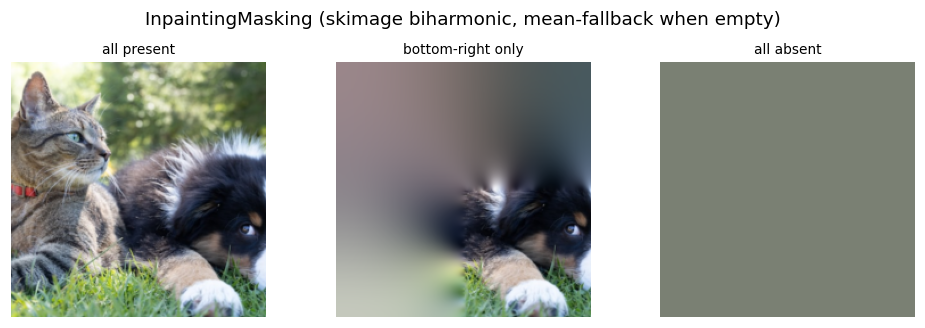

In [8]:
from skimage.restoration import inpaint_biharmonic

from shapiq.vision.masking import InpaintingMasking


def biharmonic_inpaint(img: np.ndarray, mask: np.ndarray) -> np.ndarray:
    """Cheap, deterministic, dependency-free inpainter for the demo.

    Falls back to the image mean color when every pixel is absent (biharmonic
    interpolation needs at least some known pixels).
    """
    if mask.all():
        return np.broadcast_to(img.mean(axis=(0, 1)), img.shape).astype(np.uint8)
    out = inpaint_biharmonic(img / 255.0, mask, channel_axis=-1) * 255.0
    return out.astype(np.uint8)


inpainting = InpaintingMasking(inpainter=biharmonic_inpaint)
masked = inpainting.apply(image, player_masks, batch)

fig, axes = plt.subplots(1, len(coalition_labels), figsize=(9, 3))
for ax, (label, _), m in zip(axes, coalition_labels, masked, strict=False):
    ax.imshow(m.astype(np.uint8))
    ax.set_title(label, fontsize=9)
    ax.axis("off")
plt.suptitle("InpaintingMasking (skimage biharmonic, mean-fallback when empty)")
plt.tight_layout()
plt.show()

### LayerMasking — attenuate CNN activations, not pixels

The forward hook on `layer2` multiplies activations by a downsampled spatial mask, so the
ResNet never receives an out-of-distribution input. There's no pixel-side image to display
— LayerMasking returns scores directly. Below: target-class probability per coalition vs
the same coalitions evaluated with `MeanColorMasking` for comparison.


ResNet18 target: tabby


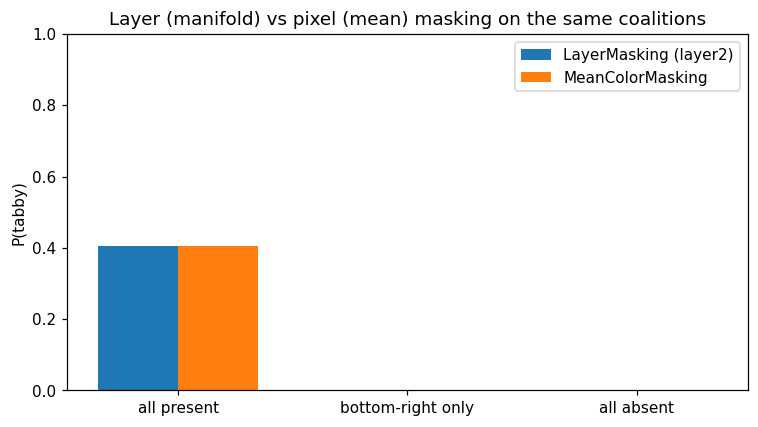

In [9]:
import torch
from torchvision.models import ResNet18_Weights, resnet18

from shapiq.vision.masking import LayerMasking, MeanColorMasking

# Raw torch module + its standard preprocess.
weights = ResNet18_Weights.DEFAULT
resnet = resnet18(weights=weights).eval().to(device)
preprocess = weights.transforms()

# Identify the target class on the unmasked image (so both strategies score the same class).
with torch.no_grad():
    target_id = int(resnet(preprocess(Image.fromarray(image)).unsqueeze(0).to(device)).argmax(-1))
target_name = weights.meta["categories"][target_id]
print("ResNet18 target:", target_name)


def preprocess_array(img: np.ndarray) -> torch.Tensor:
    return preprocess(Image.fromarray(img.astype(np.uint8)))


layer_mask = LayerMasking(layer_name="layer2")
mean_mask = MeanColorMasking()

# Layer masking returns scores directly.
layer_scores = layer_mask.value_function(
    resnet, preprocess_array, image, player_masks, batch, class_id=target_id
)

# Mean-color masking returns images; run them through ResNet for a comparable score.
mean_imgs = mean_mask.apply(image, player_masks, batch)
with torch.no_grad():
    inp = torch.stack([preprocess_array(m) for m in mean_imgs]).to(device)
    mean_scores = torch.softmax(resnet(inp), dim=-1)[:, target_id].cpu().numpy()

x = np.arange(len(coalition_labels))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width / 2, layer_scores, width=width, label="LayerMasking (layer2)")
ax.bar(x + width / 2, mean_scores, width=width, label="MeanColorMasking")
ax.set_xticks(x)
ax.set_xticklabels([label for label, _ in coalition_labels])
ax.set_ylabel(f"P({target_name})")
ax.set_ylim(0, 1)
ax.legend()
ax.set_title("Layer (manifold) vs pixel (mean) masking on the same coalitions")
plt.tight_layout()
plt.show()